In [14]:
# Task 1 — Load and verify clean_churn.csv

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/clean_churn.csv")

In [4]:
print("Final shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nData types:")
print(df.dtypes)
print("\nColumns:")
print(df.columns.tolist())

Final shape: (7035, 20)

Missing values:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate rows: 0

Data types:
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure              float64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        objec

In [18]:
## Task 2
# Problem Definition

# The goal of this machine learning problem is to predict whether a Telco customer will churn (Yes) or stay with the company (No). Predicting churn is important because the company can identify customers who are likely to leave and take actions to improve customer retention.

In [19]:
# Part 2 — Feature & Target Preparation

In [5]:
# Define the target variable
y = df["Churn"].map({"No": 0, "Yes": 1})

# Define the feature variables
X = df.drop(columns=["Churn"])

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

X shape: (7035, 19)
y shape: (7035,)

Target values:
Churn
0    5171
1    1864
Name: count, dtype: int64


In [6]:
X = pd.get_dummies(X, drop_first=True)

print("X shape after encoding:", X.shape)
print("\nData types:")
print(X.dtypes)

X shape after encoding: (7035, 34)

Data types:
SeniorCitizen                              int64
tenure                                   float64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                 bool
gender_Unknown                              bool
Partner_Unknown                             bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
InternetService_Unknown                     bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No i

In [7]:
### Encoding Justification

# One-hot encoding is used because the dataset contains categorical variables such as Contract, InternetService, and PaymentMethod. It converts each category into a separate numeric feature, which allows the Decision Tree to work with the data without assigning artificial numerical order to categories.

In [8]:
print("Any missing values in X:")
print(X.isnull().sum().sum())

print("\nAre all features numeric?")
print(X.dtypes.apply(lambda dtype: pd.api.types.is_numeric_dtype(dtype)).all())

Any missing values in X:
0

Are all features numeric?
True


In [7]:
# Part 3 — Train/Test Split

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5628, 34)
X_test shape: (1407, 34)
y_train shape: (5628,)
y_test shape: (1407,)


In [11]:
print("Original target distribution:")
print(y.value_counts(normalize=True))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Original target distribution:
Churn
0    0.735039
1    0.264961
Name: proportion, dtype: float64

Training target distribution:
Churn
0    0.735075
1    0.264925
Name: proportion, dtype: float64

Testing target distribution:
Churn
0    0.734897
1    0.265103
Name: proportion, dtype: float64


In [ ]:
### Why use stratify=y?

The Churn target is imbalanced because there are more customers who do not churn than customers who churn. Using stratify=y keeps approximately the same class distribution in both the training and test sets, making the evaluation more representative.

In [ ]:
### Task 7
# Interpretation

The dataset was split into 80% training data and 20% testing data. The training set contains 5,628 samples, while the test set contains 1,407 samples, with 34 features in both sets. The split uses stratify=y so that the Churn class distribution remains approximately the same in both training and testing data.

In [ ]:
# Part 4 — Baseline Decision Tree

In [12]:
from sklearn.tree import DecisionTreeClassifier

# Create the baseline Decision Tree
baseline_tree = DecisionTreeClassifier(random_state=42)

# Train the model
baseline_tree.fit(X_train, y_train)

# Generate predictions
y_train_pred = baseline_tree.predict(X_train)
y_test_pred = baseline_tree.predict(X_test)

print("Training predictions:", y_train_pred[:10])
print("Test predictions:", y_test_pred[:10])

Training predictions: [0 0 0 0 0 0 0 0 1 0]
Test predictions: [0 0 1 1 0 0 1 0 0 0]


In [13]:
print("Baseline tree depth:", baseline_tree.get_depth())

Baseline tree depth: 25


In [ ]:
### Task 9
# Interpretation

The baseline Decision Tree grew to a depth of 25. This is a relatively deep tree, which means the model has learned a complex set of decision rules. The large depth may indicate that the model is overfitting the training data, so we will compare its training and test performance in the next parts.

In [ ]:
# Part 5 — Model Evaluation

In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Accuracy : 0.7114427860696517
Precision: 0.45576407506702415
Recall   : 0.45576407506702415
F1-score : 0.45576407506702415


Confusion Matrix:
[[831 203]
 [203 170]]


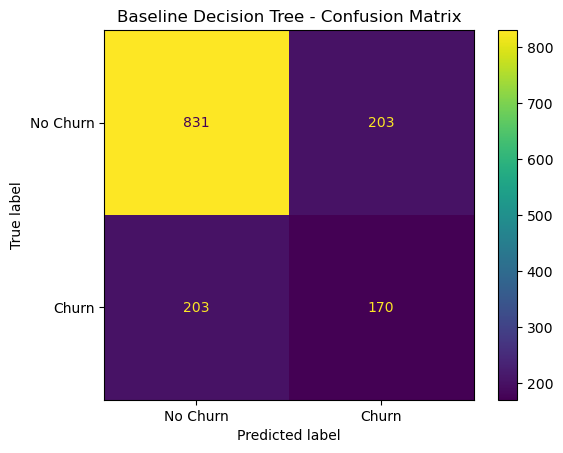

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
).plot()

plt.title("Baseline Decision Tree - Confusion Matrix")
plt.show()

In [ ]:
### Task 12
# Interpretation

The baseline Decision Tree achieved an accuracy of 71.14%, but its recall was only 45.58%, meaning it correctly identified less than half of the actual churners. The confusion matrix shows that the model correctly caught 170 churners but missed 203. Therefore, recall, along with precision and F1-score, is more informative than accuracy alone for this churn prediction problem.

In [ ]:
# Part 6 — Overfitting Investigation

In [16]:
from sklearn.metrics import accuracy_score

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)
print("Accuracy Gap:", train_accuracy - test_accuracy)

Training Accuracy: 0.9992892679459844
Test Accuracy: 0.7114427860696517
Accuracy Gap: 0.28784648187633266


In [ ]:
### Task 13 — Interpretation

The baseline Decision Tree achieved 99.93% accuracy on the training data but only 71.14% on the test data, creating a large accuracy gap of 28.79 percentage points. This indicates that the unrestricted tree has likely overfit the training data and does not generalize as well to unseen customers.

In [17]:
depths = [2, 3, 4, 5, 6, 8, 10, None]

depth_results = []

for depth in depths:
    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    
    tree.fit(X_train, y_train)
    
    train_pred = tree.predict(X_train)
    test_pred = tree.predict(X_test)
    
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    
    depth_results.append({
        "max_depth": depth,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc
    })

depth_results_df = pd.DataFrame(depth_results)

depth_results_df

,max_depth,train_accuracy,test_accuracy
0,2.0,0.763859,0.755508
1,3.0,0.770967,0.760483
2,4.0,0.778252,0.760483
3,5.0,0.794954,0.778252
4,6.0,0.803483,0.784648
5,8.0,0.828891,0.783937
6,10.0,0.867626,0.766169
7,NaN,0.999289,0.711443


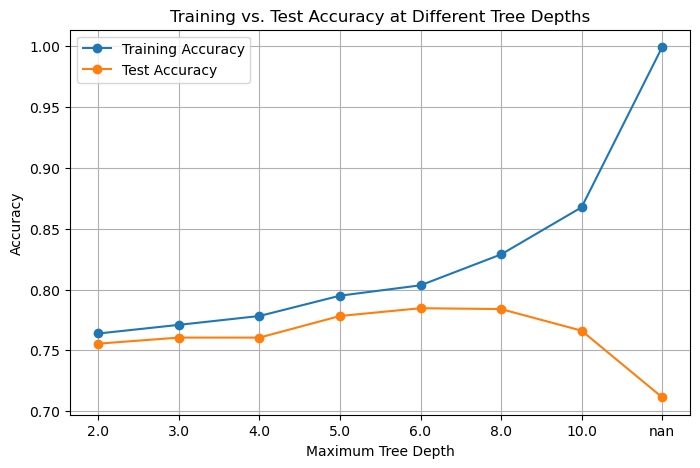

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    depth_results_df["max_depth"].astype(str),
    depth_results_df["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    depth_results_df["max_depth"].astype(str),
    depth_results_df["test_accuracy"],
    marker="o",
    label="Test Accuracy"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Training vs. Test Accuracy at Different Tree Depths")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Part 7 — Model Selection, Feature Importance & Interpretation

### Task 16 — Model Selection

Based on the depth experiment, max_depth=6 is selected as the best model. It achieved the highest test accuracy of 78.46%, while the training accuracy was 80.35%, giving a relatively small gap of about 1.89 percentage points. This provides a better balance between model performance and generalization than the deeper trees, which showed increasing signs of overfitting.

In [19]:
selected_tree = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)

selected_tree.fit(X_train, y_train)

y_selected_pred = selected_tree.predict(X_test)

In [20]:
selected_accuracy = accuracy_score(y_test, y_selected_pred)
selected_precision = precision_score(y_test, y_selected_pred)
selected_recall = recall_score(y_test, y_selected_pred)
selected_f1 = f1_score(y_test, y_selected_pred)

print("Accuracy :", selected_accuracy)
print("Precision:", selected_precision)
print("Recall   :", selected_recall)
print("F1-score :", selected_f1)

Accuracy : 0.7846481876332623
Precision: 0.631578947368421
Recall   : 0.450402144772118
F1-score : 0.5258215962441315


In [21]:
selected_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [
        selected_accuracy,
        selected_precision,
        selected_recall,
        selected_f1
    ]
})

selected_results

,Metric,Score
0,Accuracy,0.784648
1,Precision,0.631579
2,Recall,0.450402
3,F1-score,0.525822


In [22]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Baseline": [accuracy, precision, recall, f1],
    "Max Depth 6": [
        selected_accuracy,
        selected_precision,
        selected_recall,
        selected_f1
    ]
})

comparison

,Metric,Baseline,Max Depth 6
0,Accuracy,0.711443,0.784648
1,Precision,0.455764,0.631579
2,Recall,0.455764,0.450402
3,F1-score,0.455764,0.525822


In [23]:
entropy_tree = DecisionTreeClassifier(
    max_depth=6,
    criterion="entropy",
    random_state=42
)

entropy_tree.fit(X_train, y_train)

y_entropy_pred = entropy_tree.predict(X_test)

In [24]:
entropy_accuracy = accuracy_score(y_test, y_entropy_pred)
entropy_precision = precision_score(y_test, y_entropy_pred)
entropy_recall = recall_score(y_test, y_entropy_pred)
entropy_f1 = f1_score(y_test, y_entropy_pred)

print("Accuracy :", entropy_accuracy)
print("Precision:", entropy_precision)
print("Recall   :", entropy_recall)
print("F1-score :", entropy_f1)

Accuracy : 0.7860696517412935
Precision: 0.601123595505618
Recall   : 0.5737265415549598
F1-score : 0.5871056241426612


In [25]:
model_comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Baseline Gini": [accuracy, precision, recall, f1],
    "Depth 6 Gini": [
        selected_accuracy,
        selected_precision,
        selected_recall,
        selected_f1
    ],
    "Depth 6 Entropy": [
        entropy_accuracy,
        entropy_precision,
        entropy_recall,
        entropy_f1
    ]
})

model_comparison

,Metric,Baseline Gini,Depth 6 Gini,Depth 6 Entropy
0,Accuracy,0.711443,0.784648,0.786070
1,Precision,0.455764,0.631579,0.601124
2,Recall,0.455764,0.450402,0.573727
3,F1-score,0.455764,0.525822,0.587106


In [26]:
importances = selected_tree.feature_importances_

feature_importance = pd.Series(
    importances,
    index=X.columns
).sort_values(ascending=False)

print("Top 10 features:")
print(feature_importance.head(10))

Top 10 features:
PaymentMethod_Electronic check          0.292849
TotalCharges                            0.246095
Contract_Two year                       0.113865
Contract_One year                       0.083948
InternetService_Fiber optic             0.082120
StreamingMovies_No internet service     0.042858
DeviceProtection_No internet service    0.017216
MonthlyCharges                          0.017216
PaperlessBilling_Yes                    0.016640
tenure                                  0.016574
dtype: float64


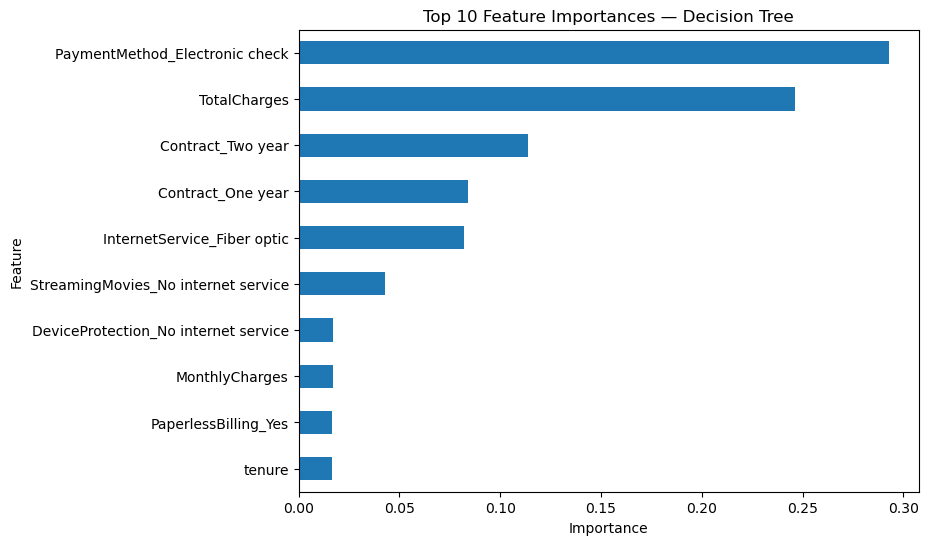

In [27]:
plt.figure(figsize=(8, 6))

feature_importance.head(10).sort_values().plot(
    kind="barh"
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances — Decision Tree")
plt.show()

In [ ]:
### Task 19 — Interpretation

The five most important features identified by the Decision Tree are PaymentMethod_Electronic check, TotalCharges, Contract_Two year, Contract_One year, and InternetService_Fiber optic. Among these, PaymentMethod_Electronic check has the highest feature importance, followed by TotalCharges. This indicates that payment method, accumulated charges, contract type, and internet service type played the largest roles in the tree's predictions.

In [ ]:
### Task 20 — Interpretation

The feature importance results are consistent with the patterns observed during the  EDA. Payment method and contract type were important factors in customer churn, and they also appear among the most important features learned by the Decision Tree. This agreement suggests that the model is capturing some of the relationships observed during the exploratory analysis.

In [ ]:
# Part 8 — Conclusion & Next Steps

### Task 21 — Conclusion

In this lab, I developed and evaluated Decision Tree classifiers for predicting customer churn using the cleaned Telco Customer Churn dataset. The unrestricted baseline tree achieved 71.14% test accuracy and showed strong overfitting, with 99.93% training accuracy compared with 71.14% test accuracy. Controlling the tree depth improved generalization, with max_depth=6 achieving 78.46% test accuracy for the Gini criterion. The depth-6 entropy model performed slightly better, achieving 78.61% accuracy, 57.37% recall, and 58.71% F1-score, so it is the preferred model for this problem. However, its recall still indicates that a considerable number of actual churners are missed, which is an important limitation.